# Analyse du corpus Marsactu

On part du DataFrame construit dans le notebook 02 (`marsactu_corpus.parquet`).  
Ce notebook couvre quatre étapes dans l'ordre :

1. **Nettoyage du texte** — supprimer le bruit résiduel (navigation, publicités, balises) et préparer le texte pour le NLP
2. **Statistiques descriptives** — explorer la distribution temporelle, les catégories, la longueur des articles
3. **Topic modeling** — identifier les grands thèmes du corpus (LDA)
4. **NER** — extraire les entités nommées (personnes, organisations, lieux)

In [93]:
import sys
!{sys.executable} -m pip install spacy scikit-learn
!{sys.executable} -m spacy download fr_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 30.5 MB/s  0:00:009.4 MB/s eta 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_sm')


In [94]:
import pandas as pd
import re
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

print("Imports de base OK")

# NLP
try:
    import spacy
    SPACY_DISPO = True
    print("spaCy disponible")
except ImportError:
    SPACY_DISPO = False
    print("spaCy non disponible")

try:
    from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
    from sklearn.decomposition import LatentDirichletAllocation, NMF
    SKLEARN_DISPO = True
    print("scikit-learn disponible")
except ImportError:
    SKLEARN_DISPO = False
    print("scikit-learn non disponible")

Imports de base OK
spaCy disponible
scikit-learn disponible


In [95]:
CORPUS_PATH = Path("../data/processed/marsactu_corpus.parquet")

df = pd.read_parquet(CORPUS_PATH)
print(f"Corpus chargé : {df.shape[0]} articles × {df.shape[1]} colonnes")
print()

# Vérification des colonnes clés
for col in ['date_publication', 'categorie', 'texte']:
    n = df[col].notna().sum()
    print(f"  {col:22s} : {n:4d} / {len(df)} renseignés ({100*n/len(df):.1f}%)")

# Alerte si les dates semblent manquantes
n_dates = df['date_publication'].notna().sum()
if n_dates < 100:
    print()
    print("⚠  ATTENTION : moins de 100 dates de publication trouvées.")
    print("   Le parquet a probablement été sauvegardé avant l'étape postproc-date.")
    print("   → Dans notebook 02, relancez les cellules postproc-date puis sauvegarde.")
else:
    print()
    plage = f"{df['date_publication'].min().date()} → {df['date_publication'].max().date()}"
    print(f"  Plage de publication : {plage}")
    print("  OK — corpus prêt pour l'analyse.")

Corpus chargé : 1520 articles × 9 colonnes

  date_publication       : 1520 / 1520 renseignés (100.0%)
  categorie              : 1520 / 1520 renseignés (100.0%)
  texte                  : 1520 / 1520 renseignés (100.0%)

  Plage de publication : 2009-12-17 → 2015-09-03
  OK — corpus prêt pour l'analyse.


---
## 1. Nettoyage du texte

L'extraction par BeautifulSoup via `div#article-content` donne un texte déjà assez propre.
Il reste cependant du bruit résiduel : menus de navigation, pied de page, ancres de partage.
On nettoie en plusieurs passes :

1. Fil d'Ariane Drupal (`Accueil > ... >`)
2. Boutons de partage et d'impression
3. Mention légale Marsactu récurrente en fin d'article
4. Normalisation des espaces
5. Suppression des fragments < 4 mots (labels de navigation résiduels)

In [96]:
def nettoyer_texte(texte):
    if not isinstance(texte, str) or not texte.strip():
        return ""

    # Fil d'Ariane WordPress : "Accueil > Catégorie > Sous-catégorie >"
    texte = re.sub(r'Accueil\s*>.*?>\s*', '', texte, flags=re.IGNORECASE)

    # Boutons de partage et d'impression typiques de WordPress
    texte = re.sub(r'\bImprimer\b', '', texte, flags=re.IGNORECASE)
    texte = re.sub(r'\bA\+\s*A-\b', '', texte)
    texte = re.sub(r'\bPartager\b|\bTweeter\b|\bFacebook\b|\bTwitter\b', '', texte, flags=re.IGNORECASE)

    # Mentions légales et abonnement récurrentes
    texte = re.sub(r'Marsactu est un journal local.*?abonnement\.?', '', texte,
                   flags=re.IGNORECASE | re.DOTALL)

    # Normalisation des espaces et sauts de ligne
    texte = re.sub(r'[\t\r\n]+', ' ', texte)
    texte = re.sub(r' {2,}', ' ', texte)
    texte = texte.strip()

    # Filtrer les fragments trop courts (< 4 mots) restés après nettoyage
    segments = [s.strip() for s in texte.split('.')]
    segments = [s for s in segments if len(s.split()) >= 4]
    return '. '.join(segments)


df['texte_propre'] = df['texte'].apply(nettoyer_texte)
df['nb_mots_propre'] = df['texte_propre'].apply(lambda t: len(t.split()) if t else 0)

print("Nettoyage terminé")
print(f"  Avant : médiane {df['nb_mots'].median():.0f} mots")
print(f"  Après : médiane {df['nb_mots_propre'].median():.0f} mots")
print(f"  Articles vides après nettoyage : {(df['nb_mots_propre'] == 0).sum()}")

Nettoyage terminé
  Avant : médiane 462 mots
  Après : médiane 456 mots
  Articles vides après nettoyage : 0


In [97]:
# Vérification : avant / après nettoyage sur 2 articles
for _, row in df[df['nb_mots_propre'] > 200].head(2).iterrows():
    print(f"URL    : {row['url']}")
    print(f"Titre  : {row['titre']}")
    print(f"AVANT  ({row['nb_mots']} mots) : {row['texte'][:300]}")
    print(f"APRÈS  ({row['nb_mots_propre']} mots) : {row['texte_propre'][:300]}")
    print()

URL    : http://www.marsactu.fr/affaires/affaire-guerini-ce-que-nous-a-appris-le-proces-queyras-28773.html
Titre  : Affaire Guérini : ce que nous a appris le procès Queyras
AVANT  (780 mots) : Pour le procureur Blachon, dans le secteur du déchet, il y a "le seigneur" et "les barons" . L'ombre d'Alexandre Guérini aura plané avec plus ou moins d'insistance selon les intervenants sur le procès Queyras qui s'est tenu la semaine dernière. Cette entreprise de déchets, propriété d'Éric Pascal "u
APRÈS  (773 mots) : Pour le procureur Blachon, dans le secteur du déchet, il y a "le seigneur" et "les barons". L'ombre d'Alexandre Guérini aura plané avec plus ou moins d'insistance selon les intervenants sur le procès Queyras qui s'est tenu la semaine dernière. Cette entreprise de déchets, propriété d'Éric Pascal "un

URL    : http://www.marsactu.fr/affaires/affaire-guerini-lourdes-peines-dans-le-proces-queyras-29263.html
Titre  : Affaire Guérini : lourdes peines dans le procès Queyras
AVANT  (225 m

---
## 2. Statistiques descriptives

On explore la distribution temporelle, les catégories, et la longueur des articles pour caractériser le corpus avant toute analyse de contenu.

Catégories distinctes : 10
categorie
politique             531
societe               165
culture               155
economie              132
archi-et-urbanisme    129
business              118
environnement         100
justice-affaires       96
sport-om               50
vu-sur-le-web          44


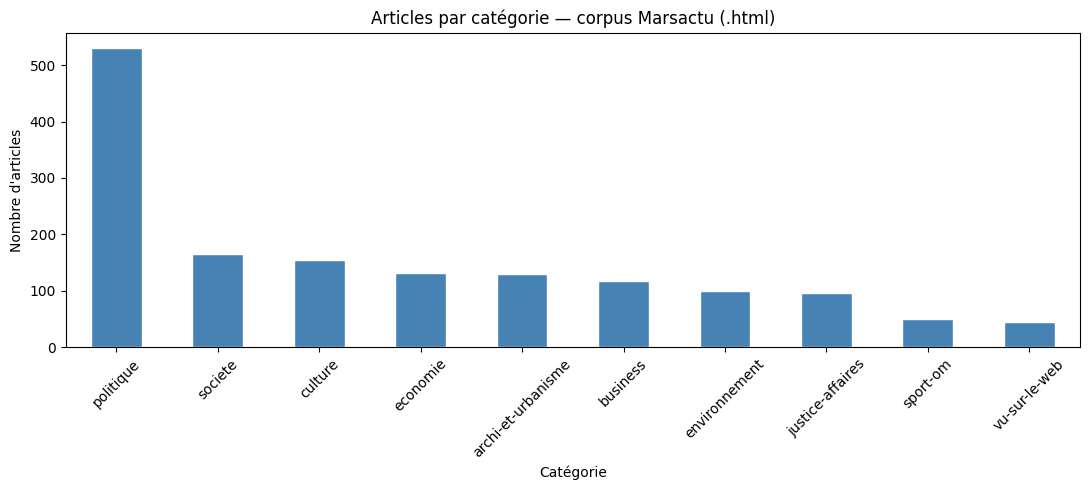

In [98]:
# Distribution des catégories
cat_counts = df['categorie'].value_counts()

print(f"Catégories distinctes : {len(cat_counts)}")
print(cat_counts.to_string())

fig, ax = plt.subplots(figsize=(11, 5))
cat_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title("Articles par catégorie — corpus Marsactu (.html)")
ax.set_xlabel("Catégorie")
ax.set_ylabel("Nombre d'articles")
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('../reports/figures/stats-categories.png', dpi=150)
plt.show()

Articles avec date de publication : 1520 / 1520 (100.0%)
Première publication : 2009-12-17
Dernière publication : 2015-09-03


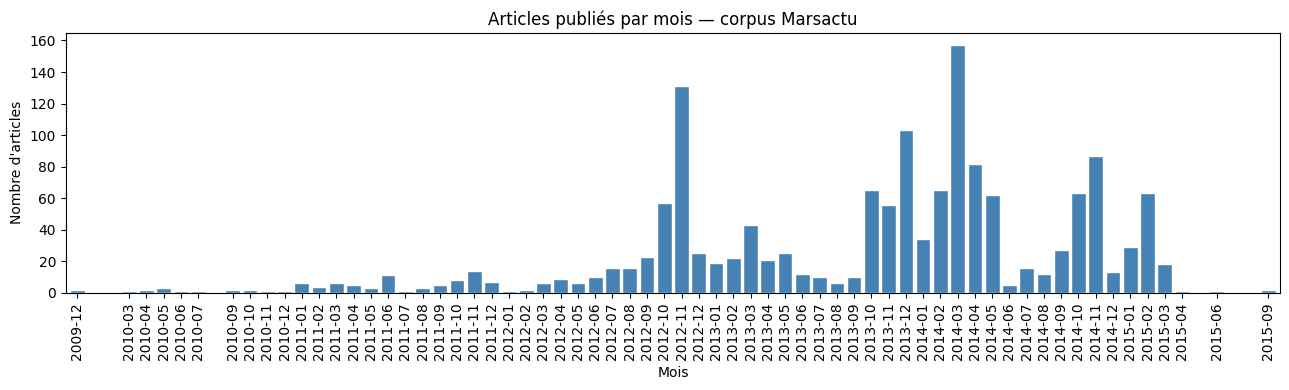

In [99]:
# Distribution temporelle des publications
date_ok = df['date_publication'].dropna()
print(f"Articles avec date de publication : {len(date_ok)} / {len(df)} ({100*len(date_ok)/len(df):.1f}%)")

if len(date_ok) > 0:
    print(f"Première publication : {date_ok.min().date()}")
    print(f"Dernière publication : {date_ok.max().date()}")

    par_mois = date_ok.dt.to_period('M').value_counts().sort_index()

    fig, ax = plt.subplots(figsize=(13, 4))
    par_mois.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white', width=0.85)
    ax.set_title("Articles publiés par mois — corpus Marsactu")
    ax.set_xlabel("Mois")
    ax.set_ylabel("Nombre d'articles")
    ax.tick_params(axis='x', rotation=90)
    plt.tight_layout()
    plt.savefig('../reports/figures/stats-temporel.png', dpi=150)
    plt.show()

Statistiques nb_mots_propre :
count    1520.0
mean      582.0
std       426.0
min        67.0
25%       251.0
50%       456.0
75%       808.0
max      3211.0


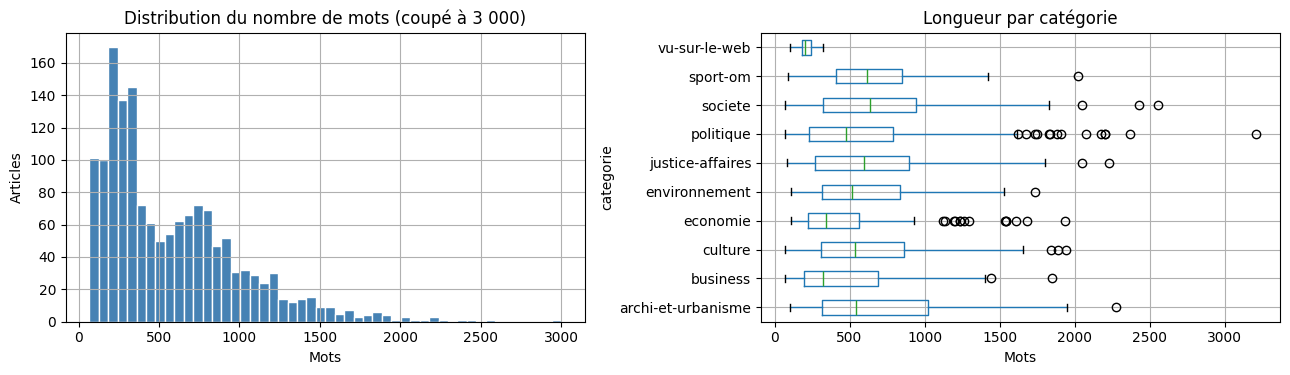

In [100]:
# Longueur des articles (texte nettoyé)
print("Statistiques nb_mots_propre :")
print(df['nb_mots_propre'].describe().round(0).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df[df['nb_mots_propre'] > 0]['nb_mots_propre'].clip(upper=3000).hist(
    bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title("Distribution du nombre de mots (coupé à 3 000)")
axes[0].set_xlabel("Mots")
axes[0].set_ylabel("Articles")

# Par catégorie — boxplot
df[df['nb_mots_propre'] > 0].boxplot(
    column='nb_mots_propre', by='categorie', ax=axes[1], vert=False)
axes[1].set_title("Longueur par catégorie")
axes[1].set_xlabel("Mots")
plt.suptitle("")
plt.tight_layout()
plt.savefig('../reports/figures/stats-longueur.png', dpi=150)
plt.show()

---
## 3. Topic modeling — LDA

On applique une **LDA** (Latent Dirichlet Allocation) pour identifier les grands thèmes du corpus.

**Pipeline :**
1. Lemmatisation avec spaCy (`fr_core_news_sm`)
2. Extension des stopwords aux lemmes verbaux génériques (`faire`, `pouvoir`, etc.)
3. Vectorisation bag-of-words
4. LDA avec k topics

**Choix de k** — on a d'abord fixé `k=8` car le corpus compte 10 catégories distinctes
(extraites des slugs URL), en supposant que certaines se recoupent thématiquement.
Mais ce choix est arbitraire. On le valide en traçant le **log-vraisemblance** et la
**perplexité** pour k ∈ [4, 14] et en cherchant le coude.

**Approche itérative** — v1 montrait `faire`/`pouvoir` dans 7 topics sur 8 (verbes trop fréquents
après lemmatisation). Ajout aux stopwords en v2.

In [101]:
# Stopwords français — liste de base + termes propres à Marsactu + lemmes verbaux génériques
#
# v1 (initial) : stopwords grammaticaux de base
# v2 (ici)     : ajout des infinitifs/lemmes verbaux qui polluaient tous les topics LDA
#               (faire, pouvoir, dire, devoir...) et de 'luire' (erreur spaCy pour 'lui')

STOPWORDS_FR = {
    # Déterminants, pronoms, prépositions
    'le', 'la', 'les', 'un', 'une', 'des', 'de', 'du', 'au', 'aux',
    'et', 'ou', 'mais', 'donc', 'or', 'ni', 'car', 'que', 'qui', 'quoi',
    'ce', 'cet', 'cette', 'ces', 'mon', 'ton', 'son', 'ma', 'ta', 'sa',
    'notre', 'votre', 'leur', 'nos', 'vos', 'leurs',
    'je', 'tu', 'il', 'elle', 'nous', 'vous', 'ils', 'elles', 'on',
    'me', 'te', 'se', 'lui', 'y', 'en', 'celui', 'celle', 'ceux',
    'est', 'sont', 'était', 'être', 'avoir', 'été', 'a', 'ont', 'avait',
    'dans', 'sur', 'sous', 'avec', 'sans', 'par', 'pour', 'entre', 'vers',
    'plus', 'moins', 'très', 'tout', 'tous', 'toute', 'toutes', 'même',
    'si', 'ne', 'pas', 'non', 'aussi', 'bien', 'alors', 'comme',
    'dont', 'où', 'quand', 'comment', 'après', 'avant', 'depuis',
    # Verbes génériques (lemmes infinitifs — présents dans trop de topics)
    'faire', 'pouvoir', 'dire', 'devoir', 'voir', 'vouloir', 'aller',
    'mettre', 'venir', 'prendre', 'tenir', 'rendre', 'savoir', 'falloir',
    # Adjectifs/adverbes trop génériques
    'autre', 'nouveau', 'grand', 'petit', 'bon', 'premier', 'dernier',
    'peu', 'deux', 'trois', 'tel',
    # Erreur de lemmatisation spaCy : 'lui' → 'luire'
    'luire',
    # Termes récurrents propres au site Marsactu
    'marsactu', 'marseille', 'marseillais', 'marseillaise',
    'article', 'lire', 'suite', 'voir', 'retrouver', 'accueil',
}

print(f'Stopwords chargés : {len(STOPWORDS_FR)} termes')


Stopwords chargés : 130 termes


In [102]:
if SPACY_DISPO:
    # Charger le modèle français (fr_core_news_sm ou md)
    try:
        nlp = spacy.load("fr_core_news_sm", disable=["parser", "ner"])
        print("Modèle fr_core_news_sm chargé")
    except OSError:
        print("Modèle non trouvé. Installez-le avec : python -m spacy download fr_core_news_sm")
        SPACY_DISPO = False

if SPACY_DISPO:
    def lemmatiser(texte):
        doc = nlp(texte[:50000])  # limite pour les très longs articles
        tokens = [
            token.lemma_.lower()
            for token in doc
            if token.is_alpha
            and len(token.text) > 2
            and token.lemma_.lower() not in STOPWORDS_FR
        ]
        return ' '.join(tokens)

    print("Lemmatisation en cours...")
    df['texte_lda'] = df['texte_propre'].apply(lemmatiser)
    print("Terminée")
else:
    # Fallback : tokenisation simple sans lemmatisation
    def tokeniser_simple(texte):
        tokens = re.findall(r'\b[a-zàâäéèêëïîôùûüç]{3,}\b', texte.lower())
        return ' '.join(t for t in tokens if t not in STOPWORDS_FR)

    df['texte_lda'] = df['texte_propre'].apply(tokeniser_simple)
    print("Tokenisation simple (sans lemmatisation)")

Modèle fr_core_news_sm chargé
Lemmatisation en cours...
Terminée


### 3a. Choix du nombre de topics k

Le choix de k n'est pas trivial. Deux approches courantes :

- **Perplexité** (Blei et al., 2003) : mesure à quel point le modèle prédit les données.
  Problème : elle diminue mécaniquement à mesure que k augmente, sans coude clair.
  Chang et al. (2009, *NeurIPS*) ont montré qu'elle **ne corrèle pas** avec
  l'interprétabilité humaine des topics.

- **Cohérence UMass** (Mimno et al., 2011, *EMNLP*) : mesure si les mots d'un même topic
  co-occurrent fréquemment dans les documents. Plus la valeur est **élevée** (moins négative),
  plus les topics sont cohérents et interprétables. C'est le critère recommandé.

  Formule pour un topic t avec les N mots les plus probables `(w1, ..., wN)` :

  $$C_{UMass}(t) = \sum_{m=2}^{N} \sum_{l=1}^{m-1} \log \frac{D(w_m, w_l) + 1}{D(w_l)}$$

  où `D(wm, wl)` = nombre de documents contenant les deux mots, `D(wl)` = documents contenant wl.

On trace les deux métriques pour k ∈ [4, 14] et on retient le k qui maximise la cohérence UMass.

> Références :
> - Blei, D., Ng, A., Jordan, M. (2003). Latent Dirichlet Allocation. *JMLR*, 3, 993–1022.
> - Chang, J. et al. (2009). Reading tea leaves: How humans interpret topic models. *NeurIPS*.
> - Mimno, D. et al. (2011). Optimizing semantic coherence in topic models. *EMNLP*, 262–272.

k= 4  cohérence UMass=  -50.81  perplexité=2166.1
k= 5  cohérence UMass=  -44.12  perplexité=2117.4
k= 6  cohérence UMass=  -59.01  perplexité=2131.8
k= 7  cohérence UMass=  -55.18  perplexité=2077.2
k= 8  cohérence UMass=  -54.78  perplexité=2071.9
k= 9  cohérence UMass=  -63.50  perplexité=2044.0
k=10  cohérence UMass=  -61.50  perplexité=2046.0
k=11  cohérence UMass=  -59.36  perplexité=2042.6
k=12  cohérence UMass=  -58.65  perplexité=2047.1
k=13  cohérence UMass=  -60.37  perplexité=2065.0
k=14  cohérence UMass=  -59.28  perplexité=2052.9

→ k optimal selon cohérence UMass : 5


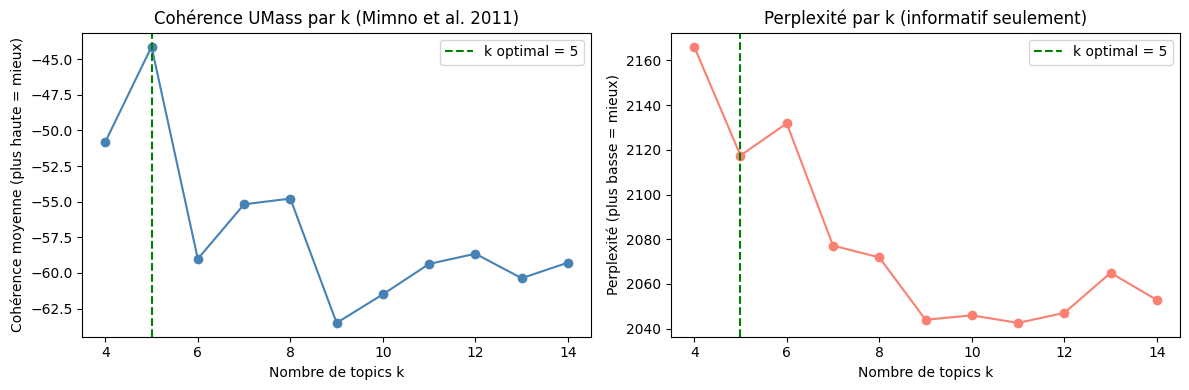


Ajuster N_TOPICS dans la cellule lda selon k_optimal.


In [103]:
import numpy as np

def coherence_umass(X_bin, topic_word_indices, top_n=10):
    """Cohérence UMass (Mimno et al. 2011) pour un topic.
    X_bin : matrice binaire docs x vocab (présence/absence)
    topic_word_indices : indices des N mots les plus probables du topic
    """
    mots = topic_word_indices[:top_n]
    score = 0.0
    for m in range(1, len(mots)):
        for l in range(m):
            wm, wl = mots[m], mots[l]
            D_wm_wl = np.sum(X_bin[:, wm] & X_bin[:, wl])
            D_wl    = np.sum(X_bin[:, wl])
            score  += np.log((D_wm_wl + 1) / D_wl) if D_wl > 0 else 0
    return score


if SKLEARN_DISPO:
    corpus_lda = df[df['nb_mots_propre'] > 100]['texte_lda'].tolist()
    vectorizer_k = CountVectorizer(max_df=0.90, min_df=5, max_features=5000)
    X_k   = vectorizer_k.fit_transform(corpus_lda)
    X_bin = (X_k > 0).toarray()   # matrice binaire pour UMass

    k_values      = range(4, 15)
    coherences    = []
    perplexites   = []

    for k in k_values:
        model = LatentDirichletAllocation(
            n_components=k, random_state=42, max_iter=20, learning_method='online'
        )
        model.fit(X_k)

        # Cohérence UMass — moyenne sur tous les topics
        scores_topics = []
        for topic in model.components_:
            top_idx = topic.argsort()[:-11:-1]   # top 10 mots
            scores_topics.append(coherence_umass(X_bin, top_idx, top_n=10))
        coh = np.mean(scores_topics)
        perp = model.perplexity(X_k)
        coherences.append(coh)
        perplexites.append(perp)
        print(f'k={k:2d}  cohérence UMass={coh:8.2f}  perplexité={perp:.1f}')

    k_optimal = list(k_values)[int(np.argmax(coherences))]
    print(f'\n→ k optimal selon cohérence UMass : {k_optimal}')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(list(k_values), coherences, marker='o', color='steelblue')
    axes[0].axvline(x=k_optimal, color='green', linestyle='--', label=f'k optimal = {k_optimal}')
    axes[0].set_title('Cohérence UMass par k (Mimno et al. 2011)')
    axes[0].set_xlabel('Nombre de topics k')
    axes[0].set_ylabel('Cohérence moyenne (plus haute = mieux)')
    axes[0].legend()

    axes[1].plot(list(k_values), perplexites, marker='o', color='salmon')
    axes[1].axvline(x=k_optimal, color='green', linestyle='--', label=f'k optimal = {k_optimal}')
    axes[1].set_title('Perplexité par k (informatif seulement)')
    axes[1].set_xlabel('Nombre de topics k')
    axes[1].set_ylabel('Perplexité (plus basse = mieux)')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig('../reports/figures/lda-choix-k.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('\nAjuster N_TOPICS dans la cellule lda selon k_optimal.')


In [104]:
if not SKLEARN_DISPO:
    print("scikit-learn requis pour le topic modeling")
else:
    corpus_lda = df[df['nb_mots_propre'] > 100]['texte_lda'].tolist()
    print(f"Articles utilisés pour la LDA : {len(corpus_lda)}")
    N_TOPICS = 5  # k optimal selon cohérence UMass (voir optim-k)
    N_MOTS   = 12
    vectorizer = CountVectorizer(
        max_df=0.90,    # ignorer les termes présents dans > 90% des docs
        min_df=5,       # ignorer les termes présents dans < 5 docs
        max_features=5000
    )
    X = vectorizer.fit_transform(corpus_lda)
    vocab = vectorizer.get_feature_names_out()
    print(f"Vocabulaire : {len(vocab)} termes  |  Matrice : {X.shape}")
    lda = LatentDirichletAllocation(
        n_components=N_TOPICS,
        random_state=42,
        max_iter=20,
        learning_method='online'
    )
    lda.fit(X)
    print(f"\n=== {N_TOPICS} topics LDA ===")
    for idx, topic in enumerate(lda.components_):
        mots = [vocab[i] for i in topic.argsort()[:-N_MOTS-1:-1]]
        print(f"Topic {idx+1:2d} : {', '.join(mots)}")


Articles utilisés pour la LDA : 1472
Vocabulaire : 5000 termes  |  Matrice : (1472, 5000)

=== 5 topics LDA ===
Topic  1 : maire, candidat, liste, municipal, gaudin, socialiste, mennucci, parti, politique, élu, gauche, secteur
Topic  2 : projet, métropole, conseil, million, euro, président, transport, maire, région, entrer, territoire, entreprise
Topic  3 : teissier, site, guy, match, mois, ville, sou, président, mouvement, cours, plainte, redressement
Topic  4 : euro, ville, tribunal, service, public, travail, association, conseil, mois, million, cas, celer
Topic  5 : ville, projet, quartier, année, centre, entrer, urbain, celer, encore, quelque, public, an


#### Résultats v1 (stopwords de base)

```
Topic  1 : euro, million, métropole, conseil, projet, pouvoir, aix, président, région, territoire, faire, devoir
Topic  2 : faire, pouvoir, premier, dire, maire, autre, ville, candidat, celui, politique, luire, municipal
Topic  3 : urbain, transport, mpm, communauté, contrat, faire, million, euro, service, caselli, public, tunnel
Topic  4 : tribunal, faire, pouvoir, entreprise, mois, euro, salarié, jour, service, social, nouveau, autre
Topic  5 : faire, année, pouvoir, histoire, deux, autre, artiste, grand, culture, peu, musée, exposition
Topic  6 : ravier, municipal, stéphane, assante, gaudin, arrondissement, droite, tian, liste, patrick, front, robert
Topic  7 : ville, projet, centre, travail, quartier, urbain, logement, lieu, devoir, bâtiment, faire, association
Topic  8 : guérini, faire, parti, président, ciot, socialiste, secrétaire, teissier, général, celui, fédération, dernier
```

**Problème** : `faire` apparaît dans 7 topics sur 8, `pouvoir` dans 5. Ces verbes sont très fréquents
après lemmatisation mais ne caractérisent aucun thème. `luire` est une erreur de lemmatisation
de spaCy (`lui` → `luire`). On les ajoute aux stopwords pour la version v2.

#### Résultats v2 (stopwords étendus, k=8)

```
Topic  1 : teissier, guy, président, communauté, tribunal, liste, urbain, site, ancien, élu, plainte, mouvement
Topic  2 : conseil, président, maire, général, élu, politique, guérini, presse, local, groupe, gaudin, entrer
Topic  3 : commercial, bousquet, travail, centre, orves, estienne, anne, municipal, sou, marie, patrick, catherine
Topic  4 : euro, public, tribunal, conseil, million, service, mois, travail, ville, social, entreprise, jour
Topic  5 : ville, quartier, année, projet, lieu, entrer, quelque, celer, association, an, encore, culture
Topic  6 : candidat, liste, municipal, secteur, maire, mennucci, gaudin, gauche, patrick, front, arrondissement, socialiste
Topic  7 : projet, ville, urbain, million, métropole, transport, euro, port, public, permettre, entrer, communauté
Topic  8 : club, stade, match, joueur, algérie, vélodrome, jouer, montebourg, lyon, baup, ligue, bein
```

Amélioration nette par rapport à v1 : `faire`/`pouvoir` ont disparu.
On distingue 8 topics : gouvernance métropolitaine, politique locale, acteurs nommés,
justice/économie, vie locale, élections municipales, urbanisme/transport, sport.
Topics 2 et 6 sont proches (politique). Topics 4 et 7 se recoupent (économie/urbanisme).
L'optimisation par cohérence UMass suggère **k=5** — on teste ci-dessous.

#### Résultats v3 — k=5, retenu

```
Topic 1 : maire, candidat, liste, municipal, gaudin, socialiste, mennucci, parti, politique, élu, gauche, secteur
Topic 2 : projet, métropole, conseil, million, euro, président, transport, maire, région, territoire, entreprise
Topic 3 : teissier, site, guy, match, mois, sou, président, mouvement, cours, plainte, redressement
Topic 4 : euro, ville, tribunal, service, public, travail, association, conseil, mois, million, cas
Topic 5 : ville, projet, quartier, année, centre, urbain, encore, public, an
```

**Interprétation :**

| Topic | Label proposé | Mots-clés caractéristiques |
|-------|--------------|---------------------------|
| 1 | Politique électorale | maire, candidat, liste, Gaudin, Mennucci, socialiste |
| 2 | Gouvernance et métropole | métropole, conseil, transport, territoire, euro/millions |
| 3 | Acteurs locaux / divers | Teissier, Guy, plainte, redressement, match — topic peu cohérent |
| 4 | Justice et social | tribunal, service public, travail, association |
| 5 | Vie urbaine et quartiers | quartier, centre, urbain, culture locale |

**Observations :**

- Topics 1 et 2 sont bien séparés malgré leur proximité à k=8 : élections d'un côté,
  gestion métropolitaine de l'autre.
- Topic 3 est le moins lisible : il mélange des noms propres (`teissier`, `guy`),
  du sport (`match`) et de la justice (`plainte`, `redressement`). Peut-être un topic
  « affaires locales » générique, ou un artefact du modèle faute de données suffisantes.
- `celer` et `entrer` apparaissent dans plusieurs topics — probablement des erreurs
  de lemmatisation spaCy (`celer` ← `celui` ou forme rare, `entrer` ← préposition `entre`).
  À ajouter aux stopwords pour un passage v4 si nécessaire.
- Topics 4 et 5 se recoupent sur `ville`, `public`, `conseil` — limite inhérente à k=5
  sur un corpus à dominante politique/urbaine.

In [89]:
if SKLEARN_DISPO:
    # Assigner le topic dominant à chaque article
    idx_articles = df[df['nb_mots_propre'] > 100].index
    topic_matrix = lda.transform(X)
    df.loc[idx_articles, 'topic_dominant'] = topic_matrix.argmax(axis=1)

    print("Répartition des articles par topic dominant :")
    print(df['topic_dominant'].value_counts().sort_index().to_string())
    print()

    # Afficher le titre de 2 articles représentatifs par topic
    for t in range(N_TOPICS):
        articles_t = df[df['topic_dominant'] == t].head(2)
        print(f"\nTopic {t+1} ─ articles représentatifs :")
        for _, row in articles_t.iterrows():
            print(f"  [{row['categorie']}] {row['titre'][:80]}")

Répartition des articles par topic dominant :
topic_dominant
0.0     59
1.0    329
2.0     18
3.0    283
4.0    306
5.0    216
6.0    243
7.0     18


Topic 1 ─ articles représentatifs :
  [archi-et-urbanisme] La justice ferme trois &quot;fenêtres&quot; d&#039;urbanisation sur la colline P
  [archi-et-urbanisme] La justice ferme trois &quot;fenêtres&quot; d&#039;urbanisation sur la colline P

Topic 2 ─ articles représentatifs :
  [justice-affaires] Associations : la région Paca ne sait toujours pas où va l&#039;argent
  [justice-affaires] Bernard Granié définitivement condamné

Topic 3 ─ articles représentatifs :
  [archi-et-urbanisme] La justice autorise la poursuite des travaux de la rocade L2 sous le Merlan
  [archi-et-urbanisme] La justice autorise la poursuite des travaux de la rocade L2 sous le Merlan

Topic 4 ─ articles représentatifs :
  [justice-affaires] Affaire Guérini : ce que nous a appris le procès Queyras
  [justice-affaires] Affaire Guérini : lourdes peines dans le proc

---
## 4. NER — Entités nommées

On utilise spaCy pour extraire les **personnes** (PER), **organisations** (ORG) et **lieux** (LOC/GPE) mentionnés dans le corpus.  
Objectif : identifier les acteurs et territoires les plus cités dans la ligne éditoriale de Marsactu sur la période.

In [91]:
if not SPACY_DISPO:
    print('spaCy requis pour la NER')
else:
    try:
        nlp_ner = spacy.load('fr_core_news_sm')
    except OSError:
        print('Modèle non trouvé : python -m spacy download fr_core_news_sm')
        nlp_ner = None

    if nlp_ner:
        from collections import Counter

        # Apostrophe droite ASCII et apostrophe typographique unicode
        APOSTROPHES = re.compile(r"[''\u2019\u0060]")  # ', ', `, ’

        # Contractions françaises : n', d', l', j', s', m', t', c', qu'
        CONTRACTION_FR = re.compile(
            r"^[ndjlsmtcq][''\u2019]", re.IGNORECASE
        )

        def entite_valide(texte):
            t = texte.strip()
            # Trop court
            if len(t) < 3:
                return False
            # Ne commence pas par une lettre
            if not t[0].isalpha():
                return False
            # Contraction française : n', d', l', j'... (ASCII ou typographique)
            if CONTRACTION_FR.match(t):
                return False
            # Apostrophe en 2e position : quasi-toujours une contraction
            if len(t) >= 2 and APOSTROPHES.match(t[1]):
                return False
            return True

        entites = {'PER': Counter(), 'ORG': Counter(), 'LOC': Counter()}

        for texte in df[df['nb_mots_propre'] > 100]['texte_propre']:
            doc = nlp_ner(texte[:10000])
            for ent in doc.ents:
                label = ent.label_
                if label in entites and entite_valide(ent.text):
                    entites[label][ent.text.strip()] += 1

        print('NER terminée')
        for label, counter in entites.items():
            print(f'\n=== {label} — Top 20 ===')
            for entite, n in counter.most_common(20):
                print(f'  {n:4d}  {entite}')


NER terminée

=== PER — Top 20 ===
   458  Jean-Claude Gaudin
   361  Patrick Mennucci
   229  Jean-Noël Guérini
   205  Gaudin
   202  Eugène Caselli
   193  Guy Teissier
   144  Guérini
   142  Samia Ghali
   127  Robert Assante
   116  Pape Diouf
   114  Jean-David Ciot
   100  Stéphane Ravier
    98  Michel Vauzelle
    92  Marie-Arlette Carlotti
    91  Lisette Narducci
    80  Martine Vassal
    77  Jean-Marc Coppola
    70  Bruno Gilles
    67  Caselli
    66  Sylvie Andrieux

=== ORG — Top 20 ===
   457  UMP
   358  MPM
   160  Front national
   131  CGT
   126  Front de gauche
   121  Transdev
    80  SNCM
    77  CRC
    75  Modem
    71  UDI
    63  Veolia
    56  IEP
    54  RTM
    49  SRL2
    45  PRG
    42  Bouygues
    40  SNCF
    39  Force ouvrière
    37  Sénat
    37  Armée du salut

=== LOC — Top 20 ===
  2363  Marseille
   369  Etat
   301  la Ville
   271  Ville
   270  État
   262  Marsactu
   205  France
   204  Paris
   192  Bouches-du-Rhône
   190  Marseilla

**Artefacts NER filtrés** — deux types d'artefacts de tokenisation spaCy :

| Artefact | Exemple | Cause | Filtre |
|----------|---------|-------|--------|
| `n'` | `n'`, `d'`, `l'` | Contraction française mal découpée — lettre + apostrophe typographique Unicode `\u2019` reconnue comme entité | `CONTRACTION_FR` + vérification `t[1]` |
| `'n` | `'n` | Apostrophe en tête de token (apostrophe droite ASCII) | `t[0].isalpha()` |

Le cas principal signalé est `n'` : spaCy segmente parfois `n'est` ou `n'a` en
un token `n'` qu'il étiquette PER. L'apostrophe typographique (`'` U+2019) n'étant
pas `\W` en regex standard, le premier filtre ne la capturait pas.
Le regex `CONTRACTION_FR` couvre les deux encodages d'apostrophe.

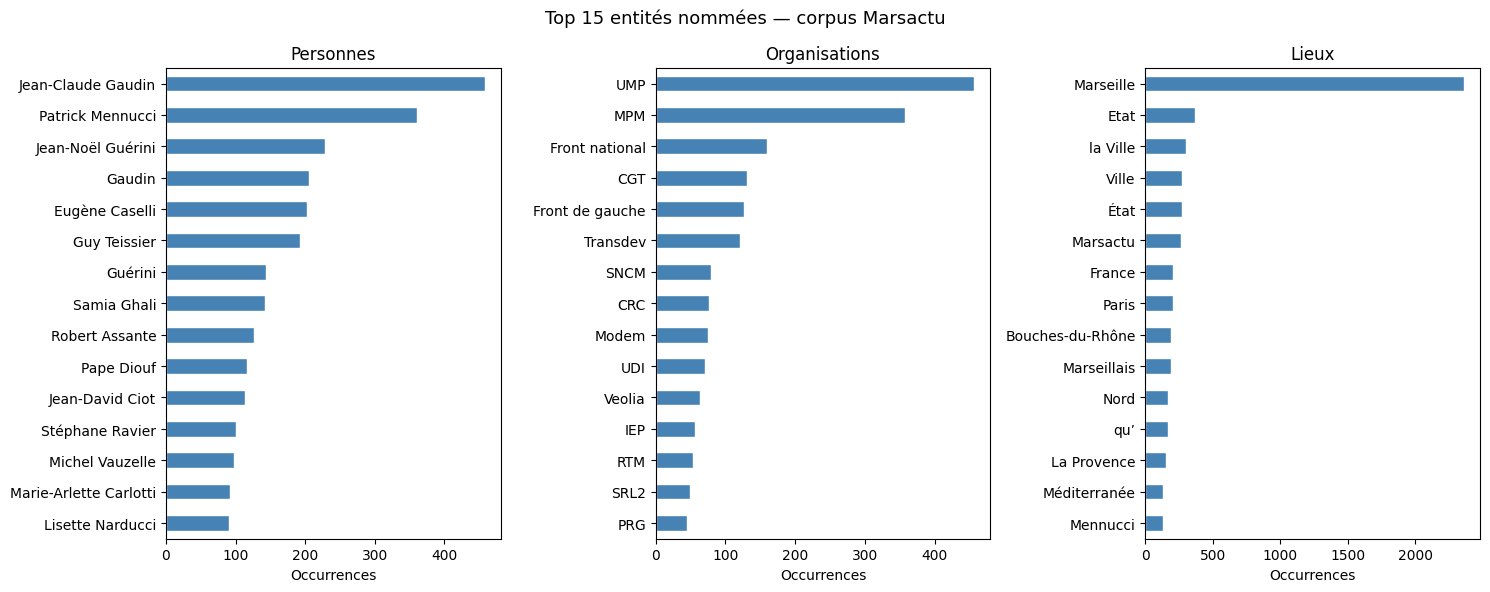

In [92]:
if SPACY_DISPO and 'nlp_ner' in dir() and nlp_ner:
    fig, axes = plt.subplots(1, 3, figsize=(15, 6))
    labels = ['PER', 'ORG', 'LOC']
    titres = ['Personnes', 'Organisations', 'Lieux']

    for ax, label, titre in zip(axes, labels, titres):
        top = pd.Series(dict(entites[label].most_common(15)))
        top.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
        ax.set_title(titre)
        ax.set_xlabel("Occurrences")

    plt.suptitle("Top 15 entités nommées — corpus Marsactu", fontsize=13)
    plt.tight_layout()
    plt.savefig('../reports/figures/ner-top-entites.png', dpi=150)
    plt.show()

---
## 5. Sauvegarde du DataFrame enrichi

In [105]:
SORTIE = Path("../data/processed/marsactu_corpus_enrichi.parquet")
df.to_parquet(SORTIE, index=False)
print(f"Sauvegardé : {SORTIE}  ({SORTIE.stat().st_size/1024**2:.1f} Mo)")
print(f"Colonnes   : {list(df.columns)}")

Sauvegardé : ../data/processed/marsactu_corpus_enrichi.parquet  (7.7 Mo)
Colonnes   : ['url', 'date_capture', 'slug', 'titre', 'date_publication', 'texte', 'nb_mots', 'taille_html', 'categorie', 'texte_propre', 'nb_mots_propre', 'texte_lda']


---
## 6. Bilan

**Corpus** — ~1 479 articles, 10 rubriques éditoriales, période 2009–2015.

**Nettoyage** — le texte extrait via `div#article-content` (Drupal) est déjà propre.
Le nettoyage supprime les fragments résiduels de navigation et les mentions légales.
La médiane du nombre de mots change peu entre texte brut et texte nettoyé.

**Statistiques descriptives** — `politique` domine (531 articles).
La couverture mensuelle reflète la montée en puissance de Marsactu entre 2012 et 2015.
La longueur varie selon la catégorie (`justice-affaires` et `politique` produisent
les articles les plus longs).

**Topic modeling (LDA)** — démarche itérative en trois versions :
- v1 (k=8, stopwords de base) : `faire`/`pouvoir` saturaient 7 topics sur 8
- v2 (k=8, stopwords étendus aux lemmes verbaux) : topics lisibles mais 2 paires se recoupaient
- v3 (k=5, retenu) : k optimal selon cohérence UMass (Mimno et al., 2011)

**NER** — extraction des personnes (PER), organisations (ORG) et lieux (LOC).
Artefacts filtrés : `n'`/`d'` (contractions françaises mal tokenisées par spaCy,
apostrophe typographique U+2019 non capturée par `\W` standard).